# Ontology × Yield — 시나리오 분석 노트북

수율 예측에서 **ontology semantic layer 가 단순 tabular CatBoost 대비 ①해석 ②학습** 양쪽에 도움이 되는지를, 시각화와 함께 한 곳에서 확인한다.

## 실제 데이터로 돌리는 법 (내일 회사에서)
1. `input/` 폴더에 계약 파일 3종을 넣는다: `raw_data.csv`, `x_feature_shap_value.csv`, `prc_metro_relation.csv` (선택: `bad_wafers.csv`).
2. **설정** 셀은 그대로 두고 (입력이 있으면 자동으로 `real` 인식), 위에서부터 차례로 실행한다.
3. `input/` 가 비어 있으면 동일 계약의 **가상데이터**를 자동 생성해 형식·동작을 먼저 확인한다.

> 아래 셀들의 출력은 **가상데이터 기준으로 미리 렌더링**돼 있다. 실제 데이터를 넣고 `Kernel ▸ Restart & Run All` 하면 동일 셀이 실데이터로 다시 채워진다.

> **평가 원칙(반드시 지킴):** "큰 N 정확도 향상"은 주장하지 않는다. 견고한 win 3가지 — **누수 차단 · 저데이터 inductive bias · 귀속이 손잡이로** — 만 본다. 정직한 한계는 `docs/model_comparison_findings.md`.

## 0. 설정 & 임포트

In [0]:
import os, sys
%matplotlib inline
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT); os.chdir(ROOT)
import pandas as pd
pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 60)
from scripts.model_comparison_demo import load_dataset, compute_results, print_report
from src.model_comparison_viz import all_figures, save_all
print('ready')

ready


## 1. 설정값
`INPUT_DIR` 에 실제 입력 3종이 있으면 `real`, 없으면 `virtual` 로 자동 동작.

In [0]:
INPUT_DIR    = 'input'   # 실제 데이터를 여기에 넣으면 자동으로 real 모드
BAD_QUANTILE = 0.80      # bad_wafers.csv 가 없을 때 fallback bad wafer 기준
ITERATIONS   = 200       # CatBoost iterations (실데이터에선 300~500 권장)
SEED         = 42
N_WAFERS     = 250       # 가상데이터 크기 (input 이 없을 때만 사용)

ds = load_dataset(INPUT_DIR, BAD_QUANTILE, N_WAFERS, SEED)
print(f'data source : {ds.source}')
print(f'wafers      : {len(ds.X)}   features: {ds.X.shape[1]}   categorical: {len(ds.cat_features)}')
print('roles       :', dict(pd.Series(ds.roles).value_counts()))

data source : virtual
wafers      : 250   features: 9   categorical: 3
roles       : {'confounder': np.int64(4), 'root_cause_candidate': np.int64(3), 'mediator_candidate': np.int64(1), 'leakage_or_post_outcome': np.int64(1)}


## 2. 해석(①) — 온톨로지 역할 분류 & 측정된 인과 사슬
이름 규칙으로 역할을 *seed* 하되, **무엇이 실제 사슬이고 얼마나 강한지는 데이터로 측정**한다 (`src/causal_evidence.py`). 표가 비어 있으면 사슬이 안 잡힌 것 — `docs/diagnosis_and_improvement_plan.md` §3 체크리스트로 원인을 본다.

In [1]:
roles_df = pd.Series(ds.roles, name='causal_role').rename_axis('feature_id').reset_index()
display(roles_df)

,feature_id,causal_role
0,cat|ppid|CVD,confounder
1,cat|eqp|CVD,confounder
2,cat|eqp_ch|CVD,confounder
3,cat|slot_n|CVD,confounder
4,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,root_cause_candidate
5,num|MET_CVD|THK_EDGE|AVG,mediator_candidate
6,num|CVD|RF_TIME_1|VALUE,root_cause_candidate
7,num|ETCH|QUEUE_TIME|VALUE,root_cause_candidate
8,num|FINAL|TARGET_PROXY|VALUE,leakage_or_post_outcome


In [2]:
med = ds.mediation.copy()
cols = ['root','mediator','n','a','b','indirect','prop_mediated','indirect_p','indirect_q',
        'bh_reject','sign_consistent','strata_stable','nonlinear_b']
display(med[cols] if not med.empty else 'NO MEASURED CHAIN — see diagnosis checklist')

,root,mediator,n,a,b,indirect,prop_mediated,indirect_p,indirect_q,bh_reject,sign_consistent,strata_stable,nonlinear_b
0,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,num|MET_CVD|THK_EDGE|AVG,250,0.938474,0.857128,0.804393,0.915909,0.0,0.0,True,True,True,False
1,num|CVD|RF_TIME_1|VALUE,num|MET_CVD|THK_EDGE|AVG,250,0.554823,0.904026,0.501574,0.925469,0.0,0.0,True,True,True,False


## 3. 학습(②) — 전체 결과 계산 (모델 1회 학습)
flat / flat-ablation / ontology 세 arm 을 동일 split·seed·iterations 로 학습하고, SHAP·매개·credit absorption·learning curve 를 한 번에 계산한다.

In [2]:
res = compute_results(ds, iterations=ITERATIONS, seed=SEED)
print_report(res)

ONTOLOGY x YIELD  --  flat vs ontology CatBoost   [data source: virtual]
  wafers=250  features=9
  roles: confounder=4, root_cause_candidate=3, mediator_candidate=1, leakage_or_post_outcome=1
1) PERFORMANCE  (regression R^2 on a held-out 25% split; identical seed/iterations)
arm                                        depth   train R2   test R2     gap
flat (all features, incl. leakage)             8      0.998     0.981   0.018
flat ablation (leakage removed by hand)        8      0.983     0.892   0.091
ontology (role-filtered + shallow)             4      0.952     0.897   0.055

  -> flat's test R2 (0.981) is inflated by the post-outcome proxy; remove it
     and the honest ceiling is ~0.892. Ontology reaches that ceiling AUTOMATICALLY via causal role.
  -> A-grade monotone priors applied to: num|MET_CVD|THK_EDGE|AVG

2) ATTRIBUTION  (top features by mean|SHAP| on the held-out fold)
  FLAT model -- points at the symptom / leakage:
     42.6%  [leakage_or_post_outcome] num|FINAL|TAR

## 4. 시각화
색상 키 = causal role: **초록 = controllable root(손잡이)**, 주황 = mediator(증상), **빨강 = leakage(제외)**, 보라 = confounder.

In [2]:
figs = all_figures(res)
paths = save_all(res, 'outputs/charts')
print('charts saved:', paths)

charts saved: ['outputs/charts/performance.png', 'outputs/charts/attribution.png', 'outputs/charts/ontology_rollup.png', 'outputs/charts/learning_curve.png', 'outputs/charts/causal_chain.png', 'outputs/charts/credit_absorption.png']


### 4-1. Performance — 누수가 부풀린 R² vs 정직한 천장

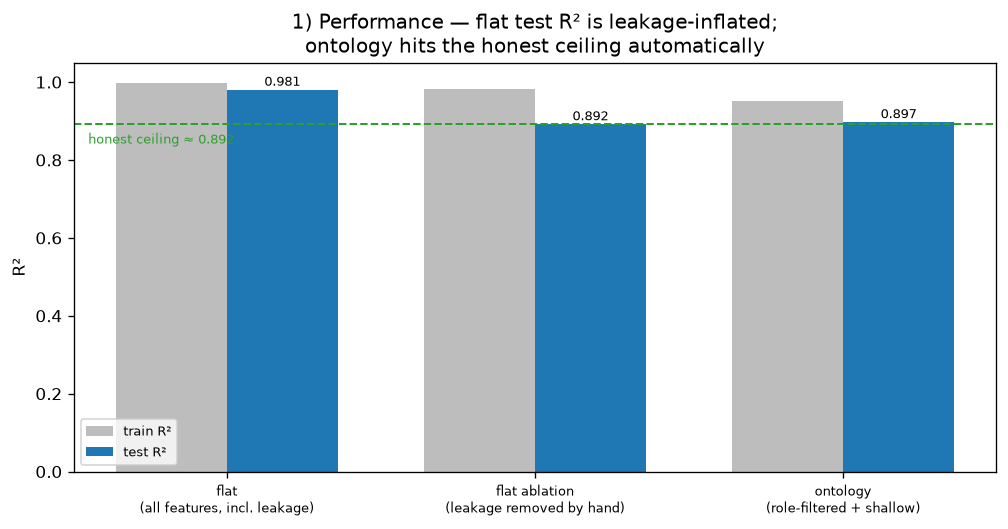

In [3]:
figs['performance']

### 4-2. Attribution — flat 은 증상/누수, ontology 는 root/mediator

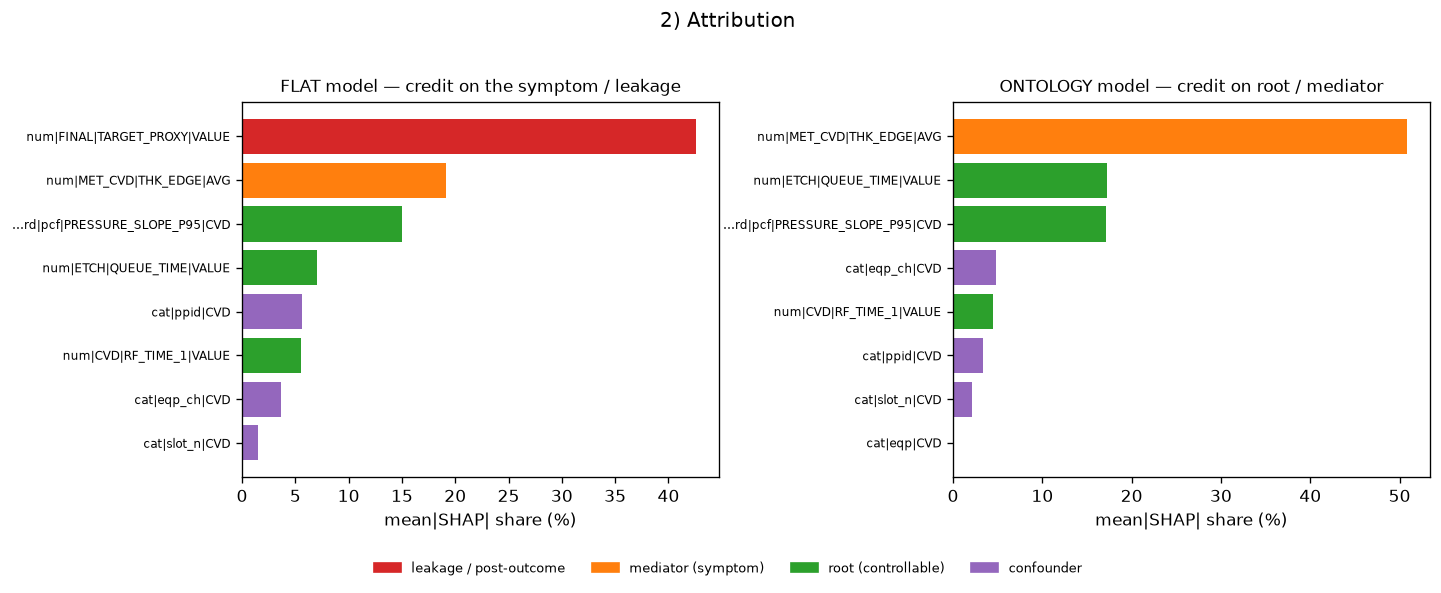

In [4]:
figs['attribution']

### 4-3. Ontology-level SHAP roll-up — controllable root 비중

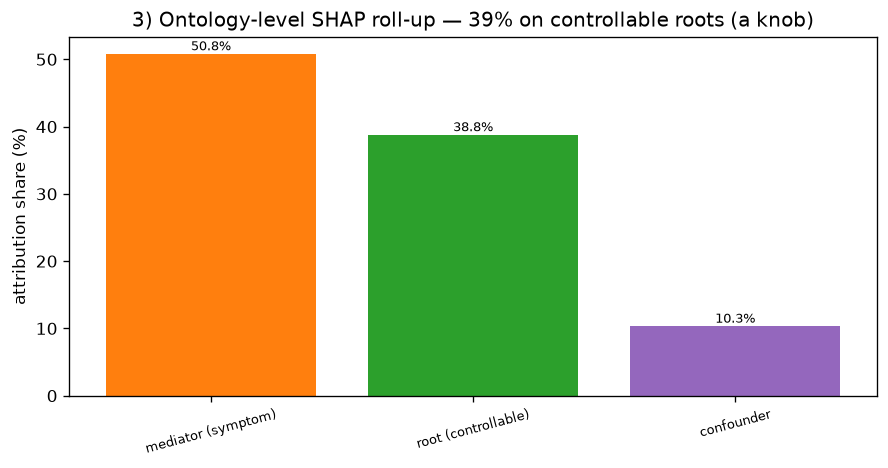

In [5]:
figs['ontology_rollup']

### 4-4. Learning curve — 저N 우위, 큰 N에서 격차 닫힘
(양 arm 모두 누수 제외; 차이는 depth 8 vs 4)

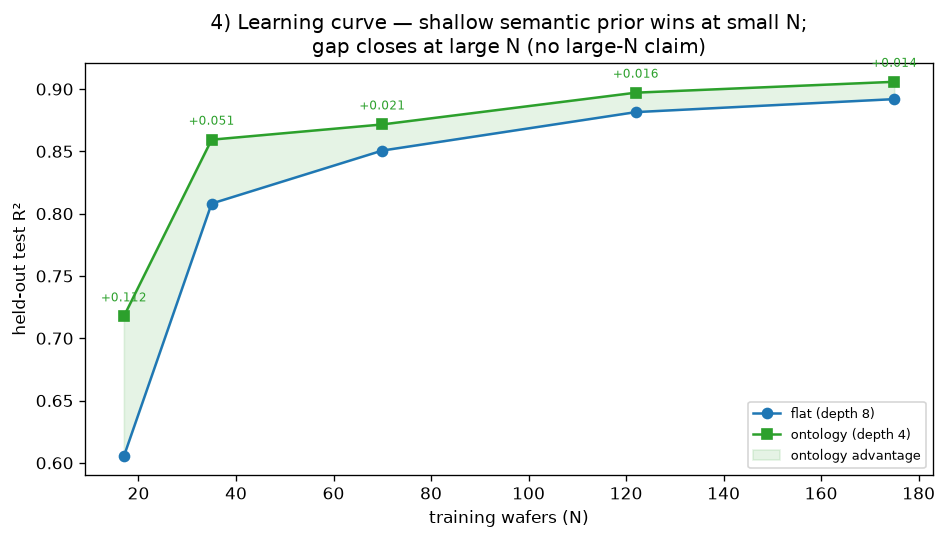

In [6]:
figs['learning_curve']

### 4-5. Measured causal chain — root → mediator → target

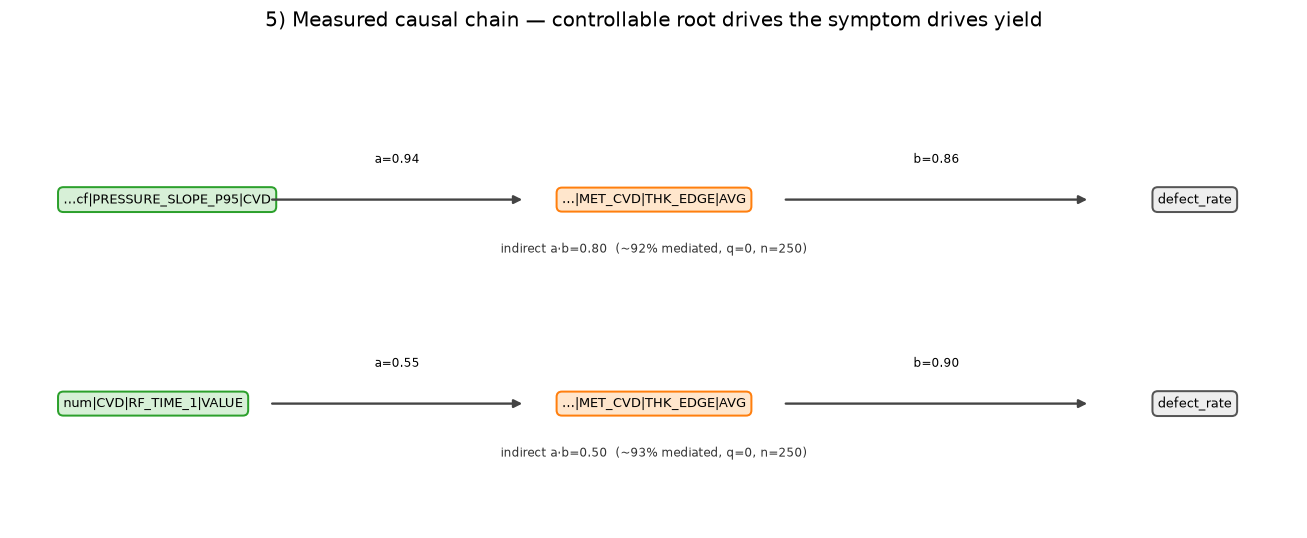

In [7]:
figs['causal_chain']

### 4-6. Credit absorption — 왜 plain SHAP 랭킹이 원인을 놓치는가

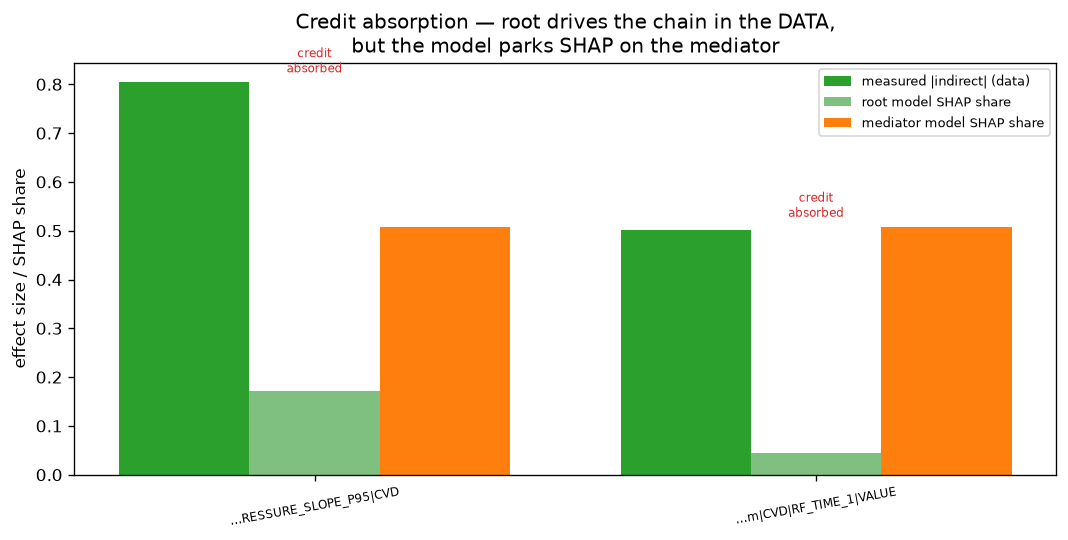

In [8]:
figs['credit_absorption']

## 5. 읽는 법 — 견고한 win 3 / 정직한 비-win

**win 1 — 누수 차단:** flat 의 높은 test R² 는 post-outcome proxy 가 부풀린 가짜. ontology 가 causal role 로 자동 제외해 *정직한 달성치*를 드러낸다 (4-1).

**win 2 — 저데이터 inductive bias:** N 이 작을수록 ontology(depth 4)가 flat(depth 8)을 이긴다 (4-4).

**win 3 — 귀속이 손잡이로:** flat SHAP 은 metro(증상)를, ontology+mediation 은 controllable root 를 지목 (4-2, 4-5, 4-6).

**정직한 비-win (먼저 말한다):** ①큰 N 정확도 향상 없음 ②CV 안정성은 setup 의존이라 헤드라인 금지 ③`prop_mediated>100%` 는 노이즈/억제 아티팩트 ④monotone 은 비단조 관계에 해로움(A-grade 에만).

**실데이터에서 사슬이 안 나오면:** `docs/diagnosis_and_improvement_plan.md` §3 — 이름 규칙 예외로 mediator 미분류 → 엣지 0개 → SHAP 랭킹 회귀. `prc_metro_relation.csv` 의 `prc_step` 문자열 일치부터 확인.